### 数据导入

In [64]:
from netCDF4 import Dataset
from cmocean import cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import os
from glob import glob
import dask
from scipy.ndimage import gaussian_filter1d
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid

file_path = r"G:\u_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_1741848707249.nc"

with Dataset(file_path, "r") as nc:
    # 全局属性
    print("全局属性:")
    for attr in nc.ncattrs():
        print(f"  {attr}: {getattr(nc, attr)}")
    
    # 所有变量信息
    print("\n变量列表:")
    for var_name in nc.variables:
        var = nc.variables[var_name]
        print(f"变量名: {var_name}")
        print(f"  维度: {var.dimensions}")
        print(f"  形状: {var.shape}")
        print(f"  数据类型: {var.dtype}")
        # 变量属性
        for attr in var.ncattrs():
            print(f"  {attr}: {getattr(var, attr)}")
        print("-" * 40)
        
u_file = r'G:\Top_up_class\data\0313\u_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_1741848707249.nc'
v_file = r'G:\Top_up_class\data\0313\v_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_1741848960539.nc'

# 读取数据
ds_u = xr.open_dataset(u_file)
ds_v = xr.open_dataset(v_file)
ds = xr.merge([ds_u, ds_v])
u = ds_u['ugos']  
v = xr.open_dataset(v_file)['vgos']
lons = xr.open_dataset(u_file)['longitude']
lats = xr.open_dataset(u_file)['latitude']
time = xr.open_dataset(u_file)['time']
time_str = time.astype(str)
#u['time'] = pd.to_datetime(u['time'].values, unit='s', origin='unix')
#v['time'] = pd.to_datetime(v['time'].values, unit='s', origin='unix')
print(time_str[0])
print('\n data size: %.1f MB' %(ds.nbytes / 1e6))
print(f'数据时间范围：start:{time_str[0].item()[0:10]};end:{time_str[-1].item()[0:10]}')
for year in range(1993,2001):
    for time_idx in range(len(time)):
        if time_str[time_idx].item()[0:10] == str(year)+'-01-01':
            print(f'idx:{time_idx}，time:{time_str[time_idx].item()[0:10]}')

全局属性:
  Conventions: CF-1.11
  title: DT merged all satellites Global Ocean Gridded SSALTO/DUACS Sea Surface Height L4 product and derived variables
  institution: CLS, CNES
  source: Altimetry measurements
  history: 2024-10-23 12:55:06Z: Creation
  contact: servicedesk.cmems@mercator-ocean.eu
  references: http://marine.copernicus.eu
  comment: Sea Surface Height measured by Altimetry and derived variables
  subset:source: ARCO data downloaded from the Marine Data Store using the MyOcean Data Portal
  subset:productId: SEALEVEL_GLO_PHY_L4_MY_008_047
  subset:datasetId: cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411
  subset:date: 2025-03-13T06:51:47.250Z

变量列表:
变量名: time
  维度: ('time',)
  形状: (2557,)
  数据类型: float64
  standard_name: time
  long_name: Time
  units: seconds since 1970-01-01 00:00:00
  calendar: gregorian
  axis: T
----------------------------------------
变量名: latitude
  维度: ('latitude',)
  形状: (199,)
  数据类型: float32
  standard_name: latitude
  long_nam

In [65]:
# Grid
ds_full = generate_grid_ds(ds, {'X': 'longitude', 'Y': 'latitude'})
grid = Grid(ds_full, periodic=['X', 'Y'])


dlong = grid.diff(ds_full.longitude, 'X', boundary='periodic')
dlonc = grid.diff(ds_full.longitude_left, 'X', boundary='periodic')
dlonc_wo_discontinuity = grid.diff(ds_full.longitude_left, 'X')  

dlatg = grid.diff(ds_full.latitude, 'Y', boundary='fill', fill_value=np.nan)
dlatc = grid.diff(ds_full.latitude_left, 'Y', boundary='fill', fill_value=np.nan)
dlatg[0]=0.25
dlatc[-1]=0.25

E:\Microsoft Edge Download\Anaconda\Lib\site-packages\xgcm\grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [5]:
def dll_dist(dlon, dlat, lon, lat):
        """Converts lat/lon differentials into distances in meters

        PARAMETERS
        ----------
        dlon : xarray.DataArray longitude differentials
        dlat : xarray.DataArray latitude differentials
        lon  : xarray.DataArray longitude values
        lat  : xarray.DataArray latitude values

        RETURNS
        -------
        dx  : xarray.DataArray distance inferred from dlon
        dy  : xarray.DataArray distance inferred from dlat
        """

        distance_1deg_equator = 111000.0
        
        dx = dlon * xr.ufuncs.cos(xr.ufuncs.deg2rad(lat)) * distance_1deg_equator
        dy = ((lon * 0) + 1) * dlat * distance_1deg_equator
        return dx, dy

In [6]:
ds_full.coords['dxg'], ds_full.coords['dyg'] = dll_dist(dlong, dlatg, ds_full.longitude, ds_full.latitude)
ds_full.coords['dxc'], ds_full.coords['dyc'] = dll_dist(dlonc, dlatc, ds_full.longitude, ds_full.latitude)
ds_full.coords['area_c'] = ds_full.dxc * ds_full.dyc
ds_full

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 2557, latitude: 199, longitude: 280,
                     longitude_left: 280, latitude_left: 199)
Coordinates:
  * time            (time) datetime64[ns] 20kB 1993-01-01 ... 2000-01-01
  * latitude        (latitude) float32 796B 1.562 1.688 1.812 ... 26.19 26.31
  * longitude       (longitude) float32 1kB 97.06 97.19 97.31 ... 131.8 131.9
  * longitude_left  (longitude_left) float32 1kB 97.0 97.12 ... 131.8 131.9
  * latitude_left   (latitude_left) float32 796B 1.5 1.625 1.75 ... 26.12 26.25
    dxg             (longitude_left, latitude) float32 223kB -3.87e+06 ... 1....
    dyg             (longitude, latitude_left) float32 223kB 2.775e+04 ... 1....
    dxc             (longitude, latitude) float32 223kB 1.387e+04 ... -3.47e+06
    dyc             (longitude, latitude) float32 223kB 1.388e+04 ... 2.775e+04
    area_c          (longitude, latitude) float32 223kB 1.924e+08 ... -9.629e+10
Data variables:
    ugos            (time, latitude, longitude) float32 570MB ...
    vgos            (time, latitude, longitude) float32 570MB ...
Attributes:
    Conventions:       CF-1.11
    title:             DT merged all satellites Global Ocean Gridded SSALTO/D...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2024-10-23 12:55:06Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_MY_008_047
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P...
    subset:date:       2025-03-13T06:51:47.250Z

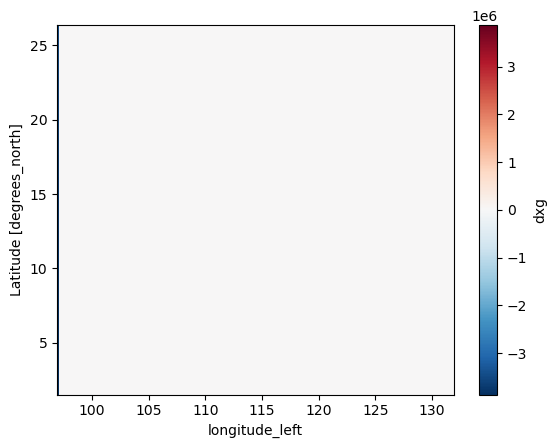

In [7]:
# dx (varis with latitude)
ds_full.dxg.plot(x='longitude_left',y='latitude')

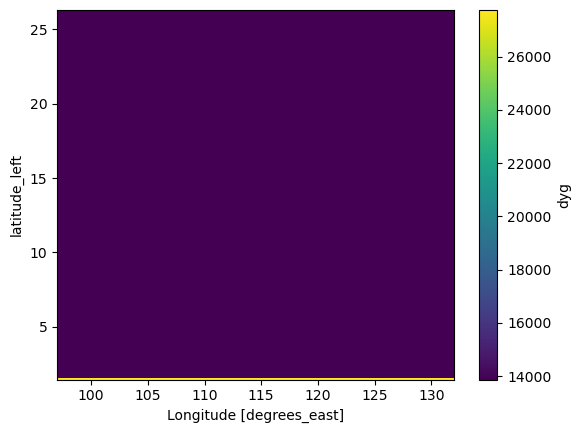

In [8]:
# dy (constant distance about 28km)
ds_full.dyg.plot(x='longitude',y='latitude_left')

## Horizontal gradients for velocity

In [9]:
du_dx = grid.diff(ds_full.ugos.where(ds.ugos>-20), 'X') / ds_full.dxg
du_dx_ij = grid.interp(du_dx, 'X')
du_dx_ij = np.real(du_dx_ij).rename('du_dx_ij') 
du_dx_ij

<xarray.DataArray 'du_dx_ij' (time: 2557, latitude: 199, longitude: 280)> Size: 570MB
array([[[ 2.0547664e-06,  3.9329934e-06,  2.3360035e-06, ...,
          1.4600023e-06,  1.3842982e-06,  6.0197368e-07],
        [-7.3175852e-07, -1.2618085e-06,  8.0395228e-07, ...,
          1.1356281e-06,  5.8043156e-07,  2.8850332e-07],
        [-3.7636835e-06, -6.1327983e-06, -2.0911361e-06, ...,
          1.6584835e-07, -2.5598342e-07,  9.4103157e-08],
        ...,
        [           nan,            nan,            nan, ...,
         -3.4900160e-07,  9.1061332e-07,            nan],
        [           nan,            nan,            nan, ...,
          3.2126422e-08,  1.0762361e-06,            nan],
        [           nan,            nan,            nan, ...,
         -1.8090594e-07,  7.1558333e-07,            nan]],

       [[ 1.9299757e-06,  3.8140308e-06,  2.0836574e-06, ...,
          1.2112613e-06,  1.5140768e-06,  9.7827092e-07],
        [-4.6793519e-07, -1.1176019e-06,  5.4798528e-07, ...,
          1.2690189e-06,  5.8764198e-07,  2.8554484e-07],
        [-3.6272986e-06, -6.1219826e-06, -2.0839254e-06, ...,
          1.6945435e-07, -3.8938416e-07, -1.8413432e-07],
...
        [           nan,            nan,            nan, ...,
         -8.1032562e-07, -2.8481747e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.0280471e-06, -5.9835526e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.5397100e-06, -1.2623211e-06,            nan]],

       [[ 2.3621817e-06,  4.4701310e-06,  2.8875602e-06, ...,
          1.6150143e-06,  1.4275573e-06,  8.5892009e-07],
        [-4.3455643e-08, -4.8669773e-07,  1.3303064e-06, ...,
          1.6836130e-06,  7.4987457e-07,  2.8461420e-07],
        [-3.3510910e-06, -5.5054570e-06, -1.4529787e-06, ...,
          5.9128718e-07,  4.5067554e-07,  3.4805714e-07],
        ...,
        [           nan,            nan,            nan, ...,
         -8.3439477e-07, -2.6074858e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.0039519e-06, -5.9835526e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.5196097e-06, -1.2341800e-06,            nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1993-01-01 1993-01-02 ... 2000-01-01
  * latitude   (latitude) float32 796B 1.562 1.688 1.812 ... 26.06 26.19 26.31
  * longitude  (longitude) float32 1kB 97.06 97.19 97.31 ... 131.7 131.8 131.9

In [10]:
du_dy = grid.diff(ds_full.ugos.where(ds.ugos>-20), 'Y') / ds_full.dyg
du_dy_ij = grid.interp(du_dy, 'Y')
du_dy_ij = np.real(du_dy_ij).rename('du_dy_ij') 
du_dy_ij

<xarray.DataArray 'du_dy_ij' (time: 2557, latitude: 199, longitude: 280)> Size: 570MB
array([[[            nan,             nan,             nan, ...,
          3.71891861e-06,  3.61261255e-06,  3.28648616e-06],
        [-5.55315319e-06, -1.14054055e-05, -1.56144142e-05, ...,
          6.25585562e-06,  5.16035971e-06,  4.61621676e-06],
        [-2.56216231e-06, -6.20180163e-06, -5.93513550e-06, ...,
          4.21981986e-06,  3.82702729e-06,  3.81981999e-06],
        ...,
        [            nan,             nan,             nan, ...,
          1.27567580e-06,  1.48468462e-06,  1.80180177e-06],
        [            nan,             nan,             nan, ...,
          1.00180159e-06,  8.43243015e-07,  8.25225243e-07],
        [            nan,             nan,             nan, ...,
          5.15315151e-07,  6.07207255e-07,  5.62162256e-07]],

       [[            nan,             nan,             nan, ...,
          3.61081106e-06,  3.62342325e-06,  3.10991004e-06],
        [-5.35135132e-06, -1.09405410e-05, -1.52828834e-05, ...,
          6.16216266e-06,  5.45585681e-06,  4.25945973e-06],
        [-2.07927928e-06, -6.12252234e-06, -5.72252247e-06, ...,
          4.25945927e-06,  3.86666716e-06,  3.85585554e-06],
...
          1.10990993e-06,  6.84684494e-07,  5.69369377e-07],
        [            nan,             nan,             nan, ...,
          5.58558611e-07,  1.08107372e-08, -3.17117127e-07],
        [            nan,             nan,             nan, ...,
          3.14774752e-06,  3.47927948e-06,  3.90090099e-06]],

       [[            nan,             nan,             nan, ...,
          6.23783762e-06,  6.79459436e-06,  6.82702648e-06],
        [-4.82522546e-06, -1.05657655e-05, -1.47963965e-05, ...,
          4.47207185e-06,  4.03603644e-06,  3.49549555e-06],
        [-2.09008931e-07, -4.26306360e-06, -3.88108037e-06, ...,
          2.11171209e-06,  1.86306295e-06,  2.40360396e-06],
        ...,
        [            nan,             nan,             nan, ...,
          1.03063053e-06,  6.45044963e-07,  4.72072259e-07],
        [            nan,             nan,             nan, ...,
          3.99999749e-07, -1.08108054e-07, -4.72072003e-07],
        [            nan,             nan,             nan, ...,
          3.32612626e-06,  3.58017996e-06,  4.02342312e-06]]],
      dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1993-01-01 1993-01-02 ... 2000-01-01
  * latitude   (latitude) float32 796B 1.562 1.688 1.812 ... 26.06 26.19 26.31
  * longitude  (longitude) float32 1kB 97.06 97.19 97.31 ... 131.7 131.8 131.9

In [15]:
dv_dx = grid.diff(ds_full.vgos.where(ds.ugos>-20), 'X') / ds_full.dxg
dv_dx_ij = grid.interp(dv_dx, 'X')
dv_dx_ij = np.real(dv_dx_ij).rename('dv_dx_ij') 
dv_dx_ij

<xarray.DataArray 'dv_dx_ij' (time: 2557, latitude: 199, longitude: 280)> Size: 570MB
array([[[ 1.9801353e-06,  4.2610441e-06,  3.1723507e-06, ...,
         -2.0259786e-06, -1.3879035e-06, -7.4880762e-07],
        [ 2.7512465e-06,  6.8966847e-06,  5.4510128e-06, ...,
         -1.6800079e-06, -9.3013313e-07, -5.7178738e-08],
        [ 2.3589575e-06,  4.0272403e-06,  9.7346015e-07, ...,
         -5.5162735e-07, -1.1537305e-07, -6.0271034e-08],
        ...,
        [           nan,            nan,            nan, ...,
         -3.4097864e-06, -2.2865622e-06,            nan],
        [           nan,            nan,            nan, ...,
         -5.0559011e-06, -3.2005978e-06,            nan],
        [           nan,            nan,            nan, ...,
         -6.0543171e-06, -4.1970166e-06,            nan]],

       [[ 1.9738427e-06,  4.0050927e-06,  2.9163998e-06, ...,
         -2.1413368e-06, -1.3770887e-06, -6.2171716e-07],
        [ 2.7476285e-06,  6.8966847e-06,  5.1878355e-06, ...,
         -1.6727976e-06, -1.3158860e-06, -3.1676367e-07],
        [ 2.2229083e-06,  4.0308455e-06,  9.7346015e-07, ...,
         -8.1482216e-07,  2.8843282e-08,  7.4085321e-08],
...
        [           nan,            nan,            nan, ...,
          2.4911496e-06,  2.6796909e-06,            nan],
        [           nan,            nan,            nan, ...,
          1.6143547e-06,  2.5901959e-06,            nan],
        [           nan,            nan,            nan, ...,
          1.2382002e-06,  2.3356959e-06,            nan]],

       [[ 1.8414547e-06,  3.7275122e-06,  2.9308194e-06, ...,
         -1.0129895e-06, -4.5422286e-07, -1.3044976e-07],
        [ 2.7468143e-06,  6.6226921e-06,  4.9498949e-06, ...,
         -4.3262014e-07,  2.3794101e-07,  5.5487271e-07],
        [ 2.0984635e-06,  3.6234346e-06,  7.3550325e-07, ...,
          6.7781656e-07,  1.2979467e-06,  6.6711669e-07],
        ...,
        [           nan,            nan,            nan, ...,
          2.2705165e-06,  2.4349883e-06,            nan],
        [           nan,            nan,            nan, ...,
          1.3975010e-06,  2.3452317e-06,            nan],
        [           nan,            nan,            nan, ...,
          1.0412139e-06,  2.0663470e-06,            nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1993-01-01 1993-01-02 ... 2000-01-01
  * latitude   (latitude) float32 796B 1.562 1.688 1.812 ... 26.06 26.19 26.31
  * longitude  (longitude) float32 1kB 97.06 97.19 97.31 ... 131.7 131.8 131.9

In [11]:
dv_dy = grid.diff(ds_full.vgos.where(ds.ugos>-20), 'Y') / ds_full.dyg
dv_dy_ij = grid.interp(dv_dy, 'Y')
dv_dy_ij = np.real(dv_dy_ij).rename('dv_dy_ij') 
dv_dy_ij

<xarray.DataArray 'dv_dy_ij' (time: 2557, latitude: 199, longitude: 280)> Size: 570MB
array([[[            nan,             nan,             nan, ...,
          3.62342348e-06,  4.22162202e-06,  5.26846861e-06],
        [ 1.15675675e-06,  1.53873862e-06,  9.22522531e-07, ...,
         -1.12072075e-06, -5.40540498e-07,  1.51351372e-07],
        [ 6.35675678e-06,  3.71531496e-06,  2.05405422e-06, ...,
         -1.09189182e-06, -3.96396445e-08,  3.78378388e-07],
        ...,
        [            nan,             nan,             nan, ...,
          1.62161683e-07, -9.87386898e-07, -1.36576477e-06],
        [            nan,             nan,             nan, ...,
          4.32434391e-08, -1.03063087e-06, -1.66486507e-06],
        [            nan,             nan,             nan, ...,
          4.18198215e-06,  4.53153098e-06,  4.47927869e-06]],

       [[            nan,             nan,             nan, ...,
          4.13153111e-06,  4.62702701e-06,  5.27567590e-06],
        [ 1.13873875e-06,  1.39099120e-06,  1.16396393e-06, ...,
         -1.26126133e-06, -5.54954966e-07,  1.44144082e-07],
        [ 6.19459479e-06,  3.69369400e-06,  2.03603622e-06, ...,
         -1.08828829e-06,  1.00900863e-07,  6.34234198e-07],
...
          5.80180199e-07,  1.40540564e-07,  6.12612496e-07],
        [            nan,             nan,             nan, ...,
          1.05225229e-06,  5.72973022e-07,  7.38738777e-07],
        [            nan,             nan,             nan, ...,
          2.03603599e-06,  1.27747751e-06,  4.68468471e-07]],

       [[            nan,             nan,             nan, ...,
          9.80180289e-07,  4.72072088e-07,  5.18918966e-07],
        [ 1.35135144e-06,  1.61081073e-06,  1.24684686e-06, ...,
         -1.18558546e-06, -2.34234179e-07,  5.65765674e-07],
        [ 6.48648620e-06,  3.86306283e-06,  2.19819822e-06, ...,
         -1.08828829e-06, -3.38738801e-07,  1.83783669e-07],
        ...,
        [            nan,             nan,             nan, ...,
          5.98198199e-07,  1.18918919e-07,  5.90991021e-07],
        [            nan,             nan,             nan, ...,
          1.02702711e-06,  5.69369377e-07,  6.91891785e-07],
        [            nan,             nan,             nan, ...,
          2.07567564e-06,  1.36936933e-06,  6.70270197e-07]]],
      dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1993-01-01 1993-01-02 ... 2000-01-01
  * latitude   (latitude) float32 796B 1.562 1.688 1.812 ... 26.06 26.19 26.31
  * longitude  (longitude) float32 1kB 97.06 97.19 97.31 ... 131.7 131.8 131.9

In [12]:
# define (real) time
import datetime
import dateutil
def iters_to_date(iters, delta_t=24*3600.):
    t0 = datetime.datetime(2012,1,1)    
    ltime = delta_t * (np.array(iters))
    dtime = [t0+dateutil.relativedelta.relativedelta(seconds=t) for t in ltime]    
    return dtime

In [13]:
time_day = iters_to_date(np.arange(2557))

In [16]:
# data for the coarse-graining approach
ds_cg = xr.merge([ds_full, du_dx_ij, du_dy_ij, dv_dx_ij, dv_dy_ij])
ds_cg = ds_cg.assign_coords(time=time_day) 
print(ds_cg)

<xarray.Dataset> Size: 3GB
Dimensions:         (latitude: 199, longitude: 280, time: 2557,
                     longitude_left: 280, latitude_left: 199)
Coordinates:
  * latitude        (latitude) float32 796B 1.562 1.688 1.812 ... 26.19 26.31
  * longitude       (longitude) float32 1kB 97.06 97.19 97.31 ... 131.8 131.9
  * longitude_left  (longitude_left) float32 1kB 97.0 97.12 ... 131.8 131.9
  * latitude_left   (latitude_left) float32 796B 1.5 1.625 1.75 ... 26.12 26.25
    dxg             (longitude_left, latitude) float32 223kB -3.87e+06 ... 1....
    dyg             (longitude, latitude_left) float32 223kB 2.775e+04 ... 1....
    dxc             (longitude, latitude) float32 223kB 1.387e+04 ... -3.47e+06
    dyc             (longitude, latitude) float32 223kB 1.388e+04 ... 2.775e+04
    area_c          (longitude, latitude) float32 223kB 1.924e+08 ... -9.629e+10
  * time            (time) datetime64[ns] 20kB 2012-01-01 ... 2018-12-31
Data variables:
    ugos            (time, lat

In [17]:
# Rechunk (no chunks along time)
chunks = {'latitude': 72, 'longitude': 72, 'time':731}            
ds_cg = ds_cg.chunk(chunks)
#ds_cg = ds_cg.isel(time=slice(248,613))
ds_cg

<xarray.Dataset> Size: 3GB
Dimensions:         (latitude: 199, longitude: 280, time: 2557,
                     longitude_left: 280, latitude_left: 199)
Coordinates:
  * latitude        (latitude) float32 796B 1.562 1.688 1.812 ... 26.19 26.31
  * longitude       (longitude) float32 1kB 97.06 97.19 97.31 ... 131.8 131.9
  * longitude_left  (longitude_left) float32 1kB 97.0 97.12 ... 131.8 131.9
  * latitude_left   (latitude_left) float32 796B 1.5 1.625 1.75 ... 26.12 26.25
    dxg             (longitude_left, latitude) float32 223kB dask.array<chunksize=(280, 72), meta=np.ndarray>
    dyg             (longitude, latitude_left) float32 223kB dask.array<chunksize=(72, 199), meta=np.ndarray>
    dxc             (longitude, latitude) float32 223kB dask.array<chunksize=(72, 72), meta=np.ndarray>
    dyc             (longitude, latitude) float32 223kB dask.array<chunksize=(72, 72), meta=np.ndarray>
    area_c          (longitude, latitude) float32 223kB dask.array<chunksize=(72, 72), meta=np.ndarray>
  * time            (time) datetime64[ns] 20kB 2012-01-01 ... 2018-12-31
Data variables:
    ugos            (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
    vgos            (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
    du_dx_ij        (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
    du_dy_ij        (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
    dv_dx_ij        (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
    dv_dy_ij        (time, latitude, longitude) float32 570MB dask.array<chunksize=(731, 72, 72), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.11
    title:             DT merged all satellites Global Ocean Gridded SSALTO/D...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2024-10-23 12:55:06Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_MY_008_047
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P...
    subset:date:       2025-03-13T06:51:47.250Z

## 2.Coarse-graining

In [18]:
# define gaussian filter 
def gaussianfilter(x, sigma, axis):
    
    return xr.apply_ufunc(gaussian_filter1d, x, sigma, axis,
                          dask='parallelized',
                          output_dtypes=[x.dtype])

In [19]:
from functools import partial
from scipy.signal import butter, filtfilt

def butter_filter(x, b, a):
    return xr.apply_ufunc(partial(filtfilt, b, a),
                          x.chunk(),
                          dask='parallelized',
                          output_dtypes=[x.dtype],
                          kwargs={'axis': 0})

In [20]:
a_10 = gaussianfilter(ds_cg.ugos, sigma=15, axis=0)

In [21]:
lowcut = 1/60

fs = 1
nyq = 0.5*fs
low = lowcut/nyq

b, a = butter(4, low, 'low')

In [22]:
b_10 = butter_filter(ds_cg.ugos, b, a)

(-0.3, 0.3)

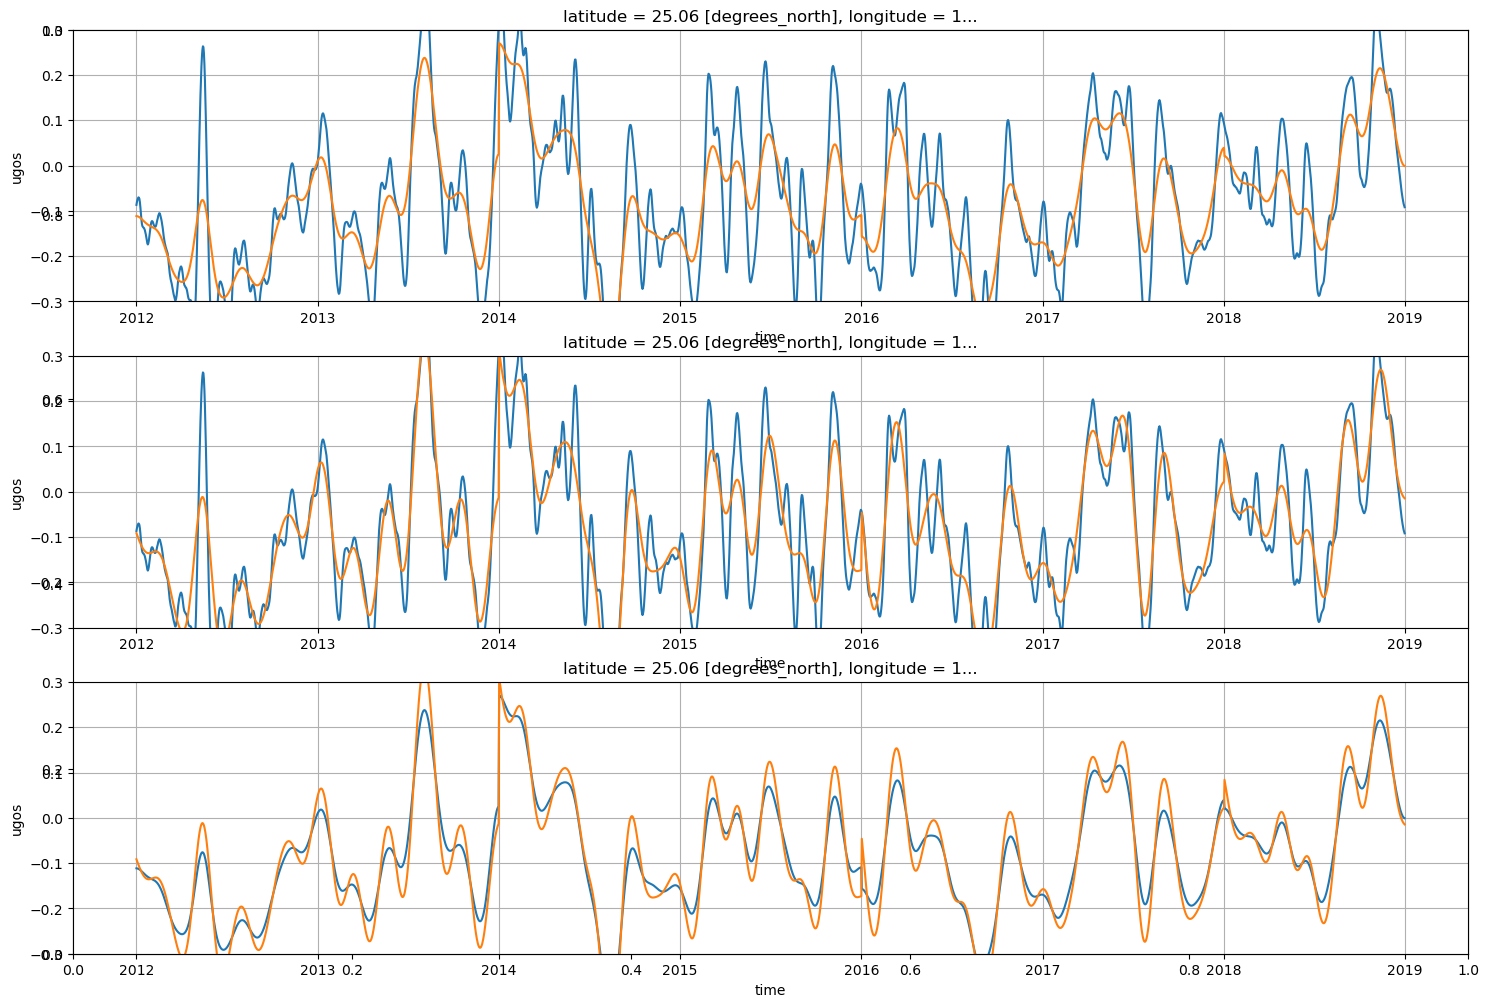

In [23]:
fig, ax = plt.subplots(figsize=(18,12))

ax = plt.subplot(311)
ds_cg.ugos.sel(latitude=25,longitude=130,method='nearest').plot()
a_10.sel(latitude=25,longitude=130,method='nearest').plot()
#b_10.sel(lat=48.6875,lon=343.8125,method='nearest').plot()
ax.grid()
ax.set_ylim([-.3, .3])

ax = plt.subplot(312)
ds_cg.ugos.sel(latitude=25,longitude=130,method='nearest').plot()
#a_10.sel(lat=48.6875,lon=343.8125,method='nearest').plot()
b_10.sel(latitude=25,longitude=130,method='nearest').plot()
ax.grid()
ax.set_ylim([-.3, .3])

ax = plt.subplot(313)
#ds_cg.u.sel(lat=48.6875,lon=343.8125,method='nearest').plot()
a_10.sel(latitude=25,longitude=130,method='nearest').plot()
b_10.sel(latitude=25,longitude=130,method='nearest').plot()
ax.grid()
ax.set_ylim([-.3, .3])

In [24]:
a_15 = gaussianfilter(ds_cg.ugos, sigma=15, axis=0)
a_30 = gaussianfilter(ds_cg.ugos, sigma=30, axis=0)
a_45 = gaussianfilter(ds_cg.ugos, sigma=45, axis=0)

In [25]:
du_dx = grid.diff(butter_filter(ds.U, b, a), 'X')/grid.interp(ds.dxG, 'Y')

AttributeError: 'Dataset' object has no attribute 'U'

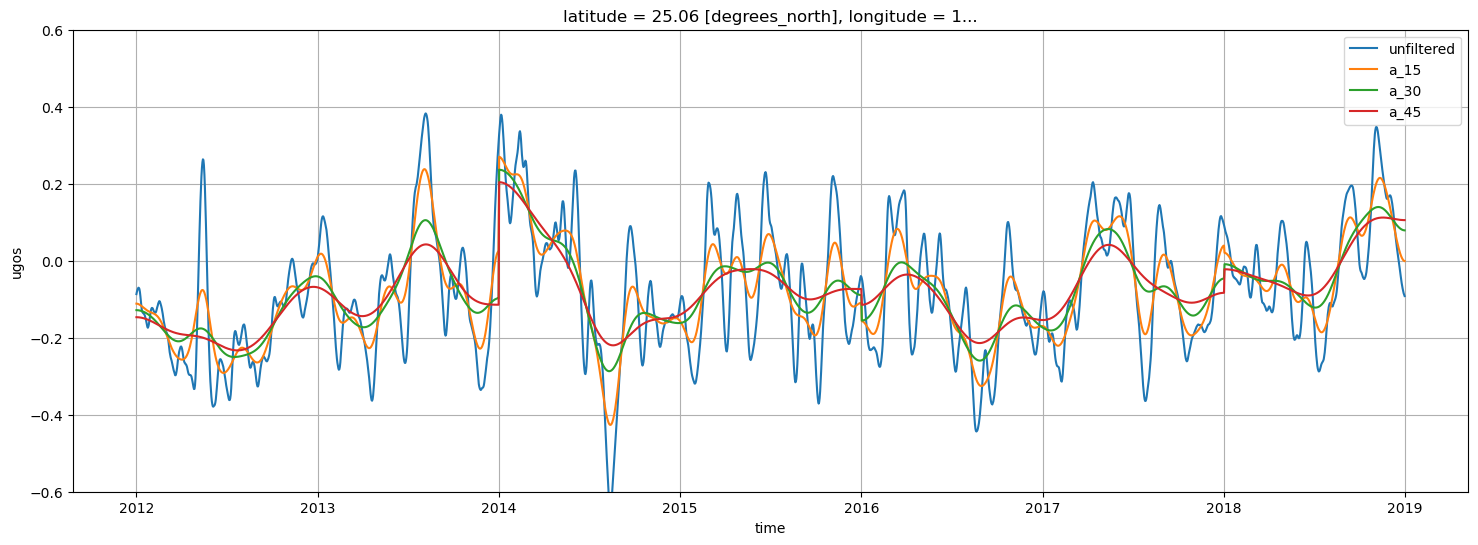

In [31]:
fig, ax = plt.subplots(figsize=(18,6))
ax = plt.subplot(111)
ds_cg.ugos.sel(latitude=25,longitude=130,method='nearest').plot(label='unfiltered')
a_15.sel(latitude=25,longitude=130,method='nearest').plot(label='a_15')
a_30.sel(latitude=25,longitude=130,method='nearest').plot(label='a_30')
a_45.sel(latitude=25,longitude=130,method='nearest').plot(label='a_45')
ax.grid()
ax.set_ylim([-.6, .6])
plt.legend()

## Culculating \Pi_w

In [32]:
store_dir_zarr = "G:\Top_up_class\data\AVISO_KER\\"

In [33]:
import os
overwrite=True
    
for sigma in [7,15,22,30]:

    Efile = store_dir_zarr+'PI_cg_sigma_%03d.zarr'%(sigma)

    if not os.path.isdir(Efile) or overwrite:

        PI_1 = ( gaussianfilter(ds_cg.ugos**2, sigma=sigma, axis=0) - gaussianfilter(ds_cg.ugos, sigma=sigma, axis=0)**2 ) * gaussianfilter(ds_cg.du_dx_ij, sigma=sigma, axis=0)
        PI_2 = ( gaussianfilter(ds_cg.vgos**2, sigma=sigma, axis=0) - gaussianfilter(ds_cg.vgos, sigma=sigma, axis=0)**2 ) * gaussianfilter(ds_cg.dv_dy_ij, sigma=sigma, axis=0)
        PI_3 = ( gaussianfilter(ds_cg.ugos*ds_cg.vgos, sigma=sigma, axis=0) - gaussianfilter(ds_cg.ugos, sigma=sigma, axis=0) * gaussianfilter(ds_cg.vgos, sigma=sigma, axis=0) ) * (gaussianfilter(ds_cg.du_dy_ij, sigma=sigma, axis=0)+gaussianfilter(ds_cg.dv_dx_ij, sigma=sigma, axis=0))

        PI_cg = -(PI_1+PI_2+PI_3)

        # store
        PI_cg = np.real(PI_cg).rename('PI_cg')
        PI_cg = PI_cg.to_dataset()        
        
        for c in PI_cg.coords:
            try:
                del PI_cg[c].encoding['chunks']
            except:
                pass
            
        %time PI_cg.to_zarr(Efile, mode='w')

        print('--- sigma %d done'%sigma)

    else:
        print('--- sigma %d allready computed'%sigma)

E:\Microsoft Edge Download\Anaconda\Lib\site-packages\zarr\api\asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: total: 47 s
Wall time: 13.7 s
--- sigma 7 done


E:\Microsoft Edge Download\Anaconda\Lib\site-packages\zarr\api\asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: total: 1min 17s
Wall time: 20.6 s
--- sigma 15 done


E:\Microsoft Edge Download\Anaconda\Lib\site-packages\zarr\api\asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: total: 1min 39s
Wall time: 25.5 s
--- sigma 22 done


E:\Microsoft Edge Download\Anaconda\Lib\site-packages\zarr\api\asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: total: 2min 8s
Wall time: 33 s
--- sigma 30 done


In [34]:
import zarr
import xarray as xr

PI_cg_sigma_030 = xr.open_zarr(store_dir_zarr+'PI_cg_sigma_007.zarr')
PI_cg_sigma_060 = xr.open_zarr(store_dir_zarr+'PI_cg_sigma_015.zarr')
PI_cg_sigma_090 = xr.open_zarr(store_dir_zarr+'PI_cg_sigma_022.zarr')
PI_cg_sigma_120 = xr.open_zarr(store_dir_zarr+'PI_cg_sigma_030.zarr')

In [35]:
PI_cg_30_cumsum = 3600*24*PI_cg_sigma_030.PI_cg.sel(time=slice('2012-09-05', '2013-09-5')).cumsum(['time'])
PI_cg_60_cumsum = 3600*24*PI_cg_sigma_060.PI_cg.sel(time=slice('2012-09-05', '2013-09-5')).cumsum(['time'])
PI_cg_90_cumsum = 3600*24*PI_cg_sigma_090.PI_cg.sel(time=slice('2012-09-05', '2013-09-5')).cumsum(['time'])
PI_cg_120_cumsum = 3600*24*PI_cg_sigma_120.PI_cg.sel(time=slice('2012-09-05', '2013-09-5')).cumsum(['time'])

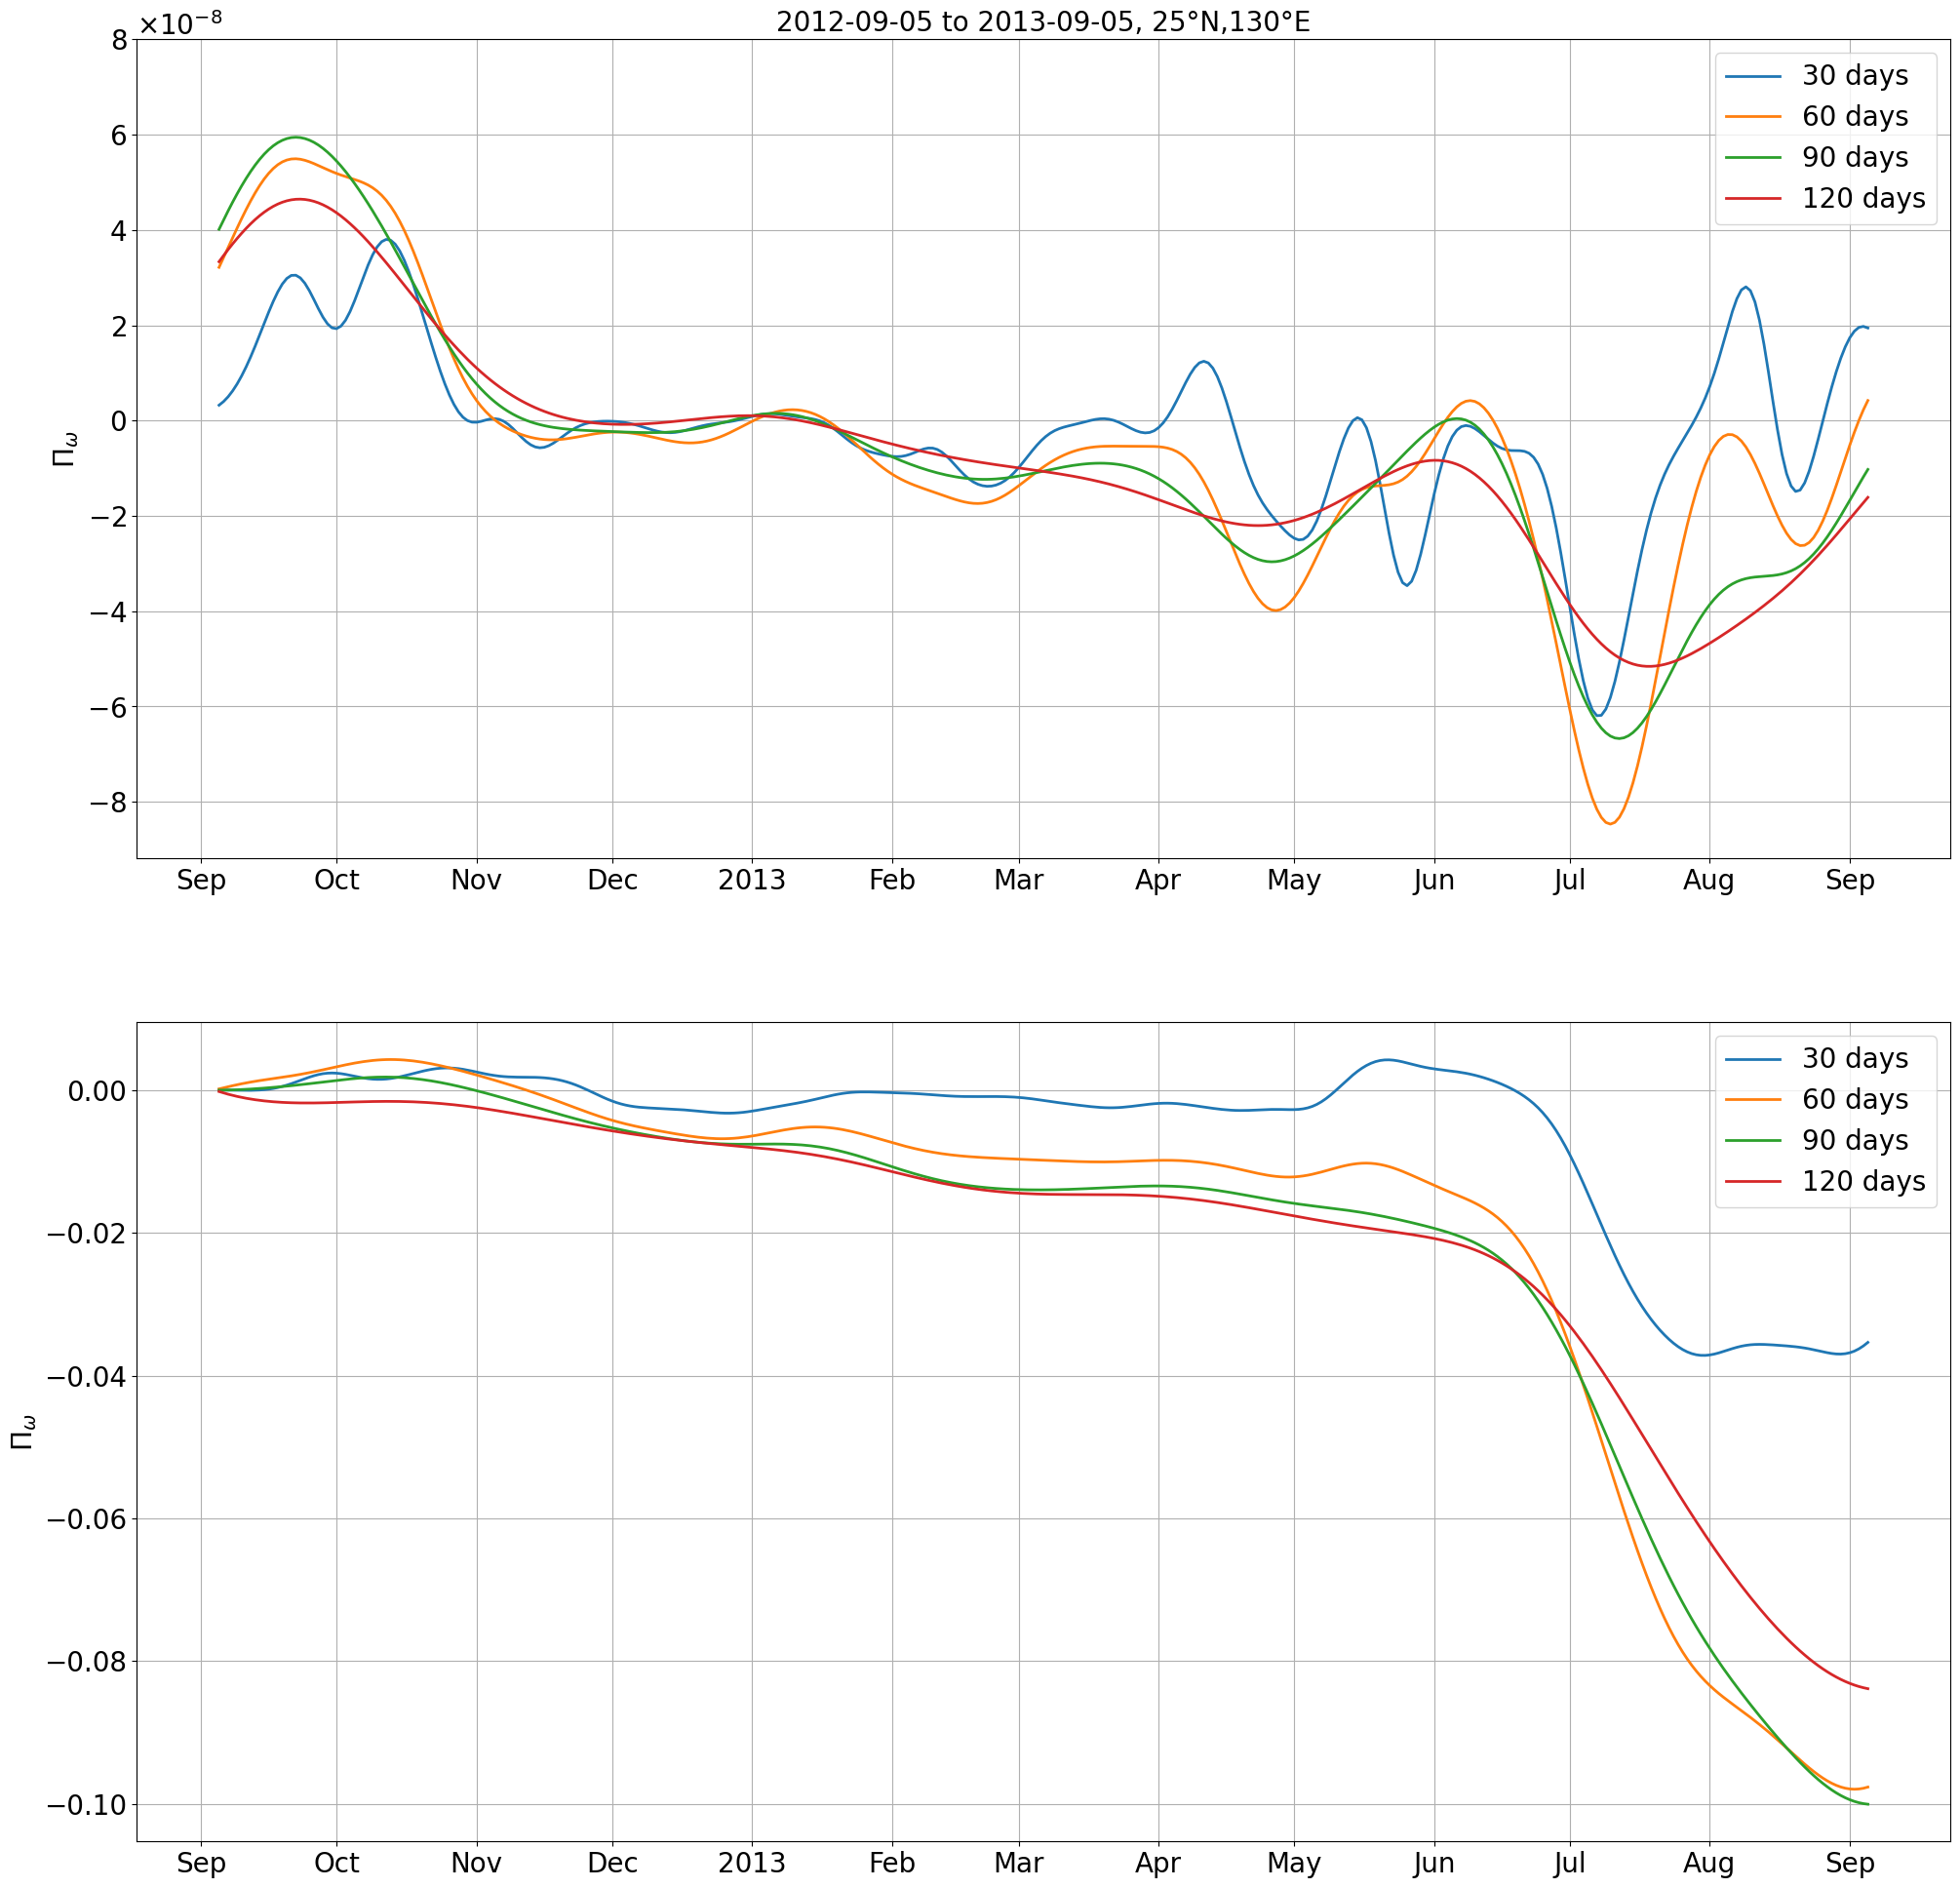

In [60]:
from matplotlib.ticker import ScalarFormatter, AutoLocator
plt.rc('font', size=20) 

font_size=20

fig = plt.figure(figsize=(24,24))
labels = ['30 days', '60 days', '90 days','120 days']
timesel = ['2012-09-05', '2013-09-05']
ax1 = plt.subplot(211)
latpt = 25
lonpt = 130

PI_cg_sigma_030.PI_cg.sel(latitude=latpt,longitude=lonpt,method='nearest').sel(time=slice(timesel[0],timesel[1])).plot(label=labels[0], linewidth=2)
PI_cg_sigma_060.PI_cg.sel(latitude=latpt,longitude=lonpt,method='nearest').sel(time=slice(timesel[0],timesel[1])).plot(label=labels[1], linewidth=2)
PI_cg_sigma_090.PI_cg.sel(latitude=latpt,longitude=lonpt,method='nearest').sel(time=slice(timesel[0],timesel[1])).plot(label=labels[2], linewidth=2)
PI_cg_sigma_120.PI_cg.sel(latitude=latpt,longitude=lonpt,method='nearest').sel(time=slice(timesel[0],timesel[1])).plot(label=labels[3], linewidth=2)

ax1.legend(); ax1.grid()
ax1.legend(prop={'size': 20})
#ax1.set_ylim([-6.5*1e-8, 6.5*1e-8])
ax1.set_xticks(['2012-09', '2012-10', '2012-11', '2012-12', '2013-01', '2013-02', '2013-03', '2013-04', '2013-05', '2013-06', '2013-07', '2013-08', '2013-09'])
ax1.set_title(f'{timesel[0]} to {timesel[1]}, {latpt}°N,{lonpt}°E',fontsize=font_size)
ax1.set_xlabel('',fontsize=font_size)
ax1.set_ylabel('$\Pi_{\omega}$',fontsize=font_size)
ax1.set_yticks(np.linspace(-8 * 1e-8, 8 * 1e-8, 6))
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax1.yaxis.set_major_locator(AutoLocator())
ax1.tick_params(labelsize=font_size)

ax2 = plt.subplot(212)
latrg = [24,26]
lonrg = [128,132]

PI_cg_30_cumsum.sel(time=slice('2012-09-05', '2013-09-05'), latitude=slice(latrg[0],latrg[1]),longitude=slice(lonrg[0],lonrg[1])).mean(['latitude','longitude']).plot(label=labels[0], linewidth=2)
PI_cg_60_cumsum.sel(time=slice('2012-09-05', '2013-09-05'), latitude=slice(latrg[0],latrg[1]),longitude=slice(lonrg[0],lonrg[1])).mean(['latitude','longitude']).plot(label=labels[1], linewidth=2)
PI_cg_90_cumsum.sel(time=slice('2012-09-05', '2013-09-05'), latitude=slice(latrg[0],latrg[1]),longitude=slice(lonrg[0],lonrg[1])).mean(['latitude','longitude']).plot(label=labels[2], linewidth=2)
PI_cg_120_cumsum.sel(time=slice('2012-09-05', '2013-09-05'), latitude=slice(latrg[0],latrg[1]),longitude=slice(lonrg[0],lonrg[1])).mean(['latitude','longitude']).plot(label=labels[3], linewidth=2)

ax2.legend(); ax2.grid()
ax2.legend(prop={'size': 20})
#ax2.set_ylim([-1.5*1e-8, 1.5*1e-8])
ax2.set_xticks(['2012-09', '2012-10', '2012-11', '2012-12', '2013-01', '2013-02', '2013-03', '2013-04', '2013-05', '2013-06', '2013-07', '2013-08', '2013-09'])
ax2.set_title('',fontsize=font_size)
ax2.set_xlabel('',fontsize=font_size)
ax2.set_ylabel('$\Pi_{\omega}$',fontsize=font_size)
ax2.tick_params(labelsize=font_size)

#plt.savefig('/home1/datawork/xyu/OSMOSIS_llc4320/Figures/Pi_omega_coarse_graining_long_periods5.png')

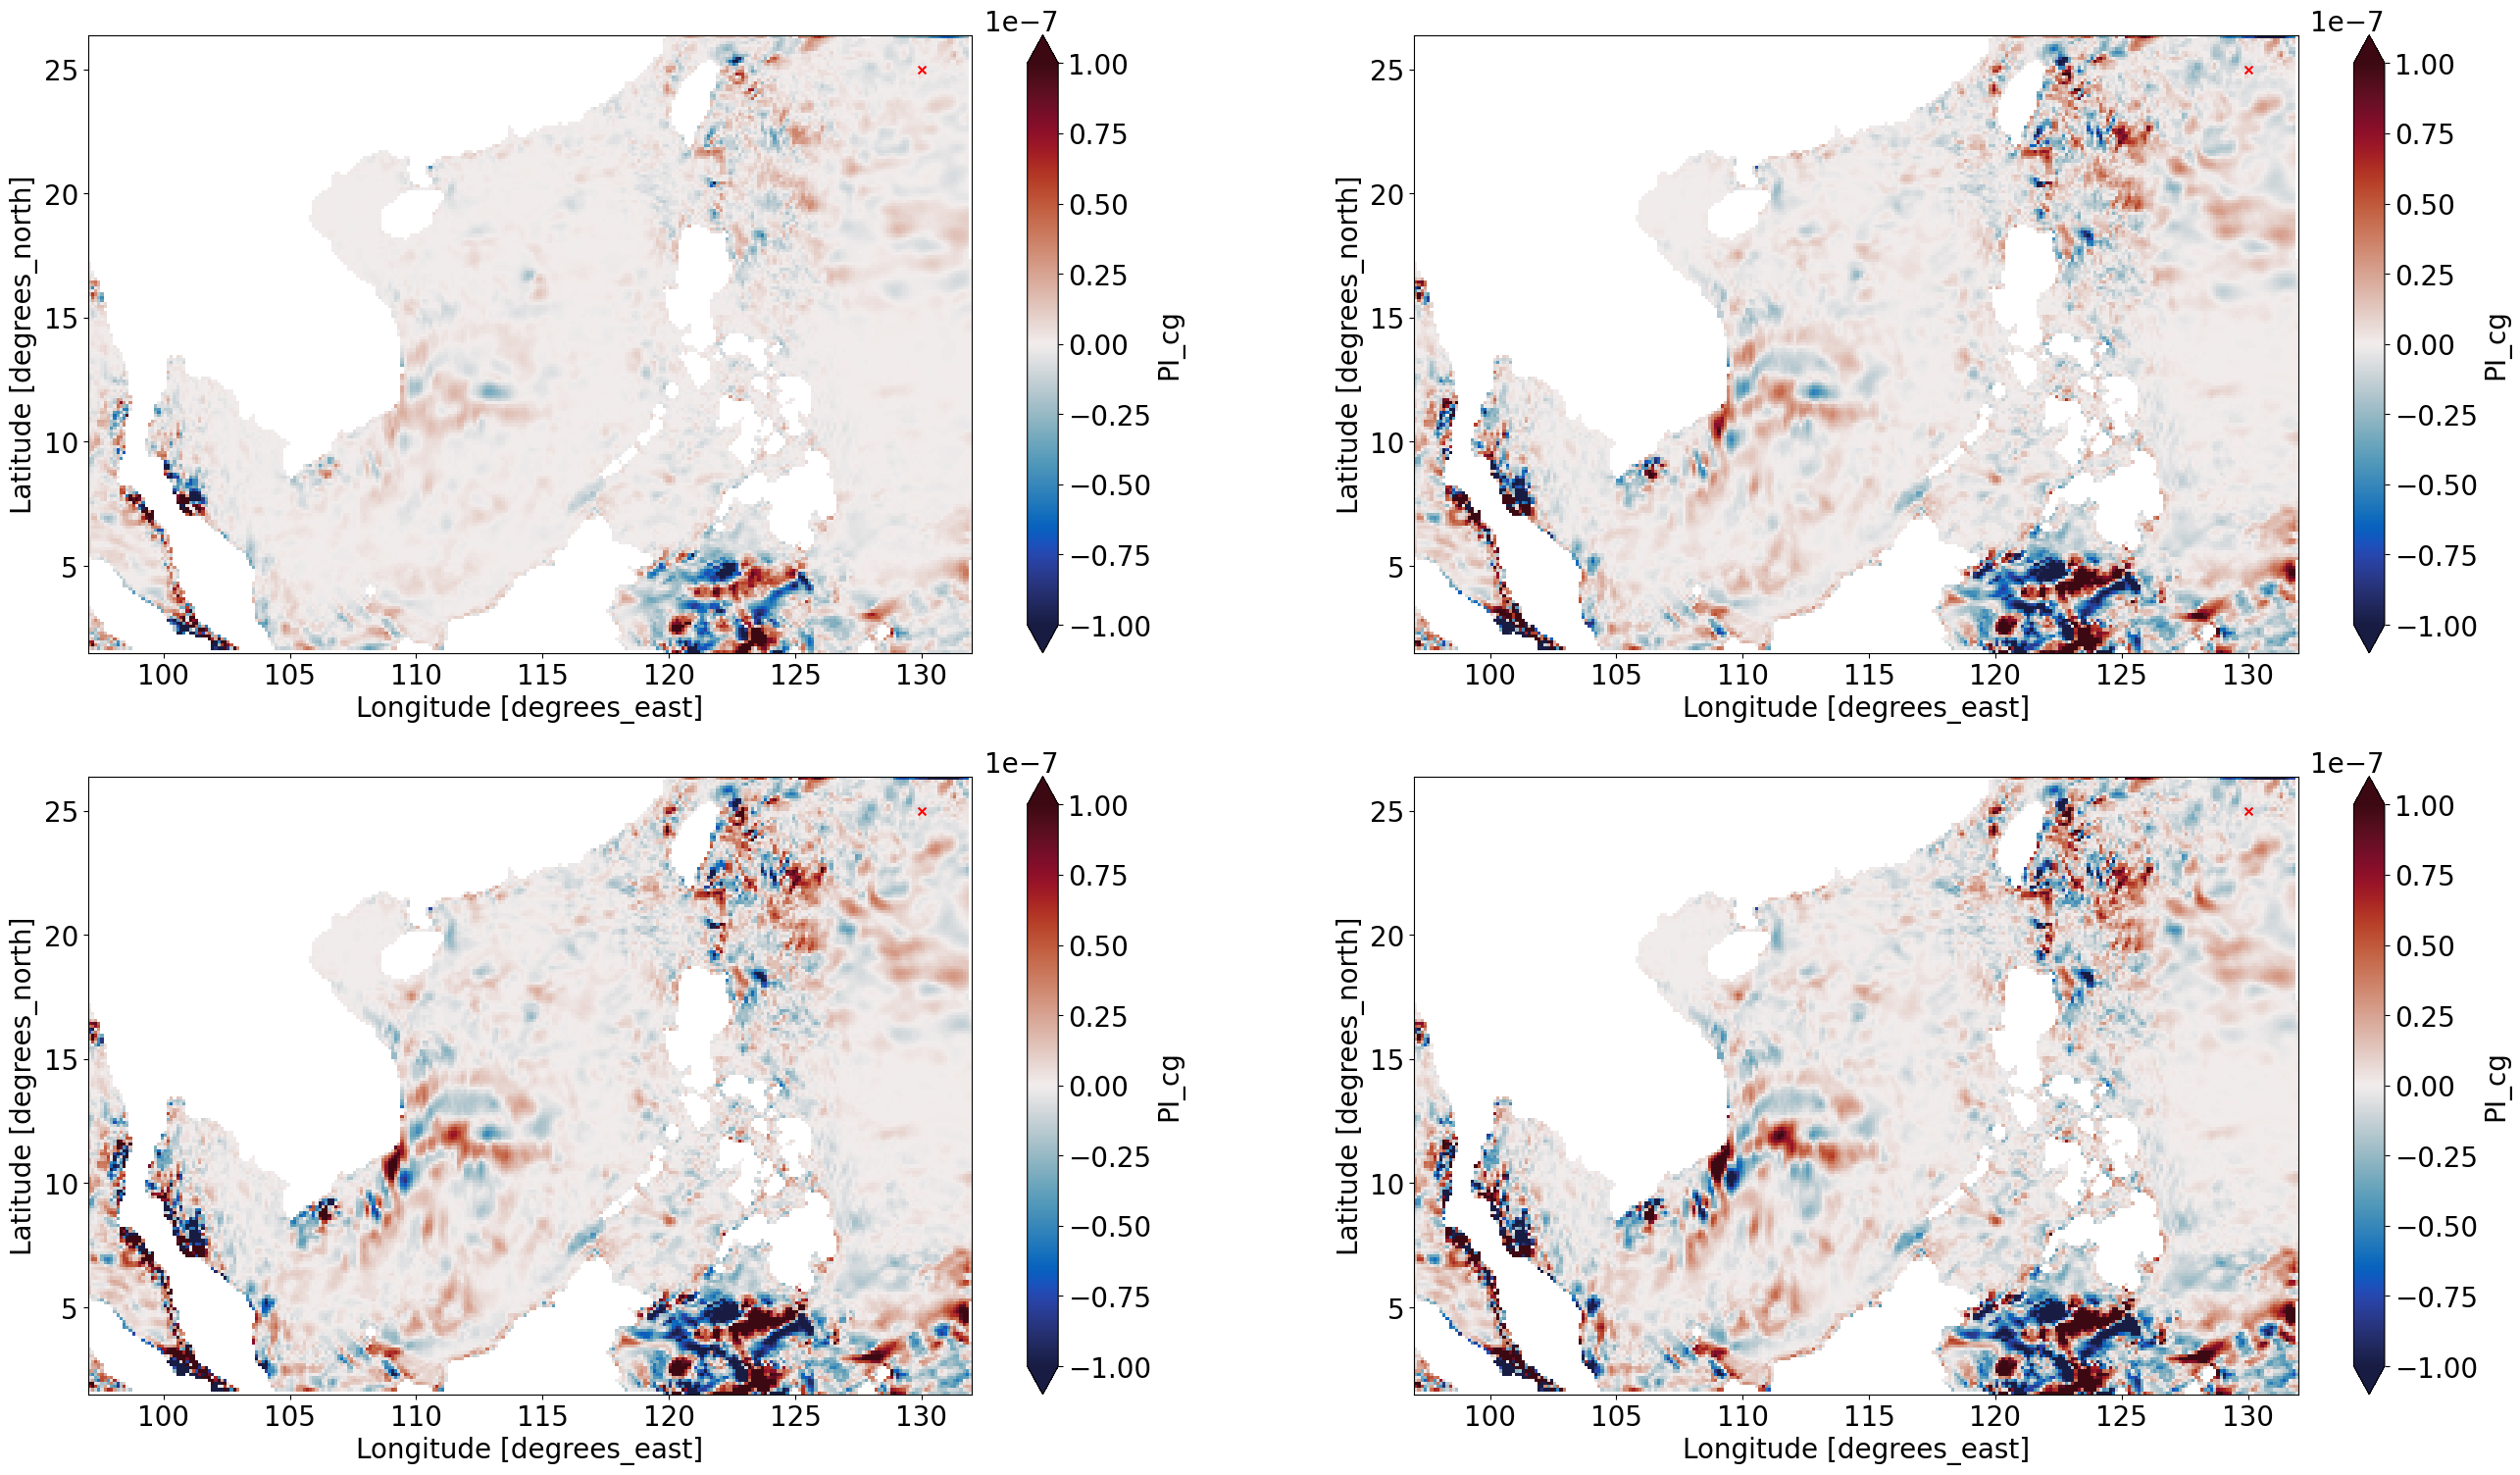

In [63]:
plt.rc('font', size=20) 

font_size=20
latpt = 25
lonpt = 130
timesel = ['2012-09-05', '2013-09-05']
fig = plt.figure(figsize=(32,18))

ax = plt.subplot(221)
PI_cg_sigma_030.PI_cg.sel(time=slice(timesel[0], timesel[1])).mean(['time']).plot(x='longitude',y='latitude',vmin=-1e-7,vmax=1e-7,cmap=cm.balance)
ax.scatter(lonpt,latpt,s=32,marker='x',color='r')
ax.tick_params(labelsize=font_size)

ax = plt.subplot(222)
PI_cg_sigma_060.PI_cg.sel(time=slice(timesel[0], timesel[1])).mean(['time']).plot(x='longitude',y='latitude',vmin=-1e-7,vmax=1e-7,cmap=cm.balance)
ax.scatter(lonpt,latpt,s=32,marker='x',color='r')
ax.tick_params(labelsize=font_size)

ax = plt.subplot(223)
PI_cg_sigma_090.PI_cg.sel(time=slice(timesel[0], timesel[1])).mean(['time']).plot(x='longitude',y='latitude',vmin=-1e-7,vmax=1e-7,cmap=cm.balance)
ax.scatter(lonpt,latpt,s=32,marker='x',color='r')
ax.tick_params(labelsize=font_size)

ax = plt.subplot(224)
PI_cg_sigma_120.PI_cg.sel(time=slice(timesel[0], timesel[1])).mean(['time']).plot(x='longitude',y='latitude',vmin=-1e-7,vmax=1e-7,cmap=cm.balance)
ax.scatter(lonpt,latpt,s=32,marker='x',color='r')
ax.tick_params(labelsize=font_size)

#plt.savefig('/home1/datawork/xyu/OSMOSIS_llc4320/Figures/Pi_omega_coarse_graining_long_periods4.png')